In [ ]:
pip install gensim numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.8 MB/s eta 0:00:00


In [29]:
import gensim
import numpy as np
from scipy.spatial.distance import cosine

In [30]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")

In [31]:
# Cosine similarity
def cosine_similarity(w1, w2):
    return 1 - cosine(model[w1], model[w2])

# Association function s(w, A, B)
def association(w, A, B):
    return np.mean([cosine_similarity(w, a) for a in A]) - \
           np.mean([cosine_similarity(w, b) for b in B])

# WEAT score
def weat_score(X, Y, A, B):
    return sum([association(x, A, B) for x in X]) - \
           sum([association(y, A, B) for y in Y])

# Effect size
def effect_size(X, Y, A, B):
    X_assoc = [association(x, A, B) for x in X]
    Y_assoc = [association(y, A, B) for y in Y]

    numerator = np.mean(X_assoc) - np.mean(Y_assoc)
    denominator = np.std(X_assoc + Y_assoc)

    return numerator / denominator

In [32]:
gender_X = ["man","male","boy","brother","he","him"]
gender_Y = ["woman","female","girl","sister","she","her"]

career_A = ["career","corporation","salary","office","business"]
family_B = ["home","family","children","parents","marriage"]

race_X = ["white","caucasian","european"]
race_Y = ["black","african","afro"]

pleasant_A = ["joy","love","peace","wonderful","pleasure"]
unpleasant_B = ["hate","pain","anger","terrible","awful"]

religion_X = ["christian","church","bible"]
religion_Y = ["muslim","islam","mosque"]

positive_A = ["good","kind","honest","peaceful"]
negative_B = ["violent","terrorist","evil","dangerous"]

In [33]:
# ----------------------------------------
# MULTIPLE WEAT TESTS MODULE
# ----------------------------------------

def filter_words(word_list):
    return [w for w in word_list if w in model]

def run_weat_test(test_name, X, Y, A, B):
    X = filter_words(X)
    Y = filter_words(Y)
    A = filter_words(A)
    B = filter_words(B)

    score = weat_score(X, Y, A, B)
    eff = effect_size(X, Y, A, B)

    print(f"\n===== {test_name} WEAT Test =====")
    print("WEAT Score:", round(score, 4))
    print("Effect Size:", round(eff, 4))

    if eff > 0:
        print("Interpretation: X is more associated with A")
    elif eff < 0:
        print("Interpretation: Y is more associated with A")
    else:
        print("Interpretation: No detectable bias")

    return eff

In [40]:
results = {}

results["Gender Bias"] = run_weat_test(
    "Gender",
    gender_X, gender_Y,
    career_A, family_B
)

results["Racial Bias"] = run_weat_test(
    "Racial",
    race_X, race_Y,
    pleasant_A, unpleasant_B
)

results["Religious Bias"] = run_weat_test(
    "Religious",
    religion_X, religion_Y,
    positive_A, negative_B
)



===== Gender WEAT Test =====
WEAT Score: 0.281
Effect Size: 0.4563
Interpretation: X is more associated with A

===== Racial WEAT Test =====
WEAT Score: -0.0984
Effect Size: -0.7141
Interpretation: Y is more associated with A

===== Religious WEAT Test =====
WEAT Score: 0.2634
Effect Size: 1.7112
Interpretation: X is more associated with A


In [41]:
if eff_size > 0.1:
    print("Interpretation: Effect Size > 0")
    print("Target group X is more associated with A (Bias towards X-A).")
elif eff_size < -0.1:
    print("Interpretation: Effect Size < 0")
    print("Target group Y is more associated with A (Bias towards Y-A).")
else:
    print("Interpretation: Effect Size ≈ 0")
    print("No detectable bias.")

Interpretation: Effect Size > 0
Target group X is more associated with A (Bias towards X-A).


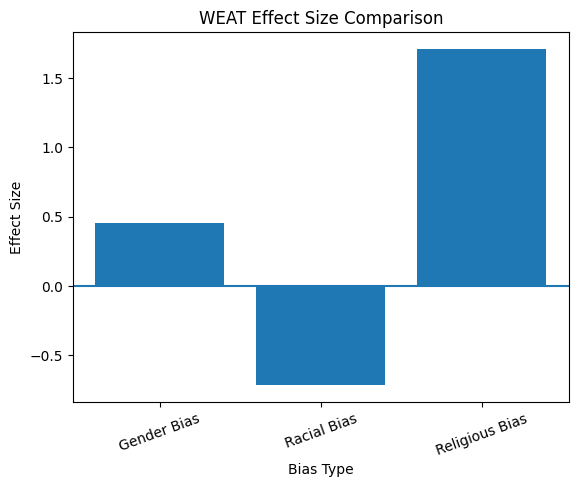

In [42]:
import matplotlib.pyplot as plt

def visualize_results(results_dict):
    tests = list(results_dict.keys())
    effect_sizes = list(results_dict.values())

    plt.figure()
    plt.bar(tests, effect_sizes)
    plt.axhline(0)

    plt.xlabel("Bias Type")
    plt.ylabel("Effect Size")
    plt.title("WEAT Effect Size Comparison")
    plt.xticks(rotation=20)

    plt.show()

# Call visualization
visualize_results(results)